In [20]:
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# notebook dir
notebook_dir = os.path.dirname(os.path.abspath('__file__'))
print('notebook_dir', notebook_dir)

# config auto reload
%load_ext autoreload
%autoreload 2

notebook_dir /home/mingxuan/Repositories/scg_tsung/benchmarking_sim/quadrotor/plotting
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [21]:
SYS = 'quadrotor_2D_attitude'
controller = 'mpc_acados'
controller = 'linear_mpc_acados'
controller = 'ilqr'
controller = 'lqr'
controller = 'pid'
controller = 'gpmpc_acados_TP'
controller = 'fmpc'

tag = ''
# tag = '_proc_ns=5'
# tag = '_ob_ns=3'
# tag = '_dw_h=2dot5'
# tag = '_tr'
noise_type = 'obs_noise'
# noise_type = 'proc_noise'

if controller in ['gpmpc_acados_TP']:
    prior = f'_100_200{tag}_{noise_type}_quadrotor_2D_attitude'
    data_folder_dir = f'../{controller}/results/{prior}'
else:
    prior = f'results_{noise_type}_{SYS}'
    data_folder_dir = f'../{controller}/{prior}'

max_seed = 10
metric_name = 'metrics.txt'
s = 2 # times std

# get the default color cycle
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
plot_color = {'ilqr': 'slateblue', 
              'lqr': 'blueviolet',
              'gpmpc_acados_TP': colors[0], 
              'mpc_acados': colors[-1], 
              'linear_mpc_acados':"green",
              'fmpc': "darkblue",
              'pid': 'tab:gray',
              } 


In [22]:
# find the folder in the dir
seed_data_folder = os.listdir(os.path.join(notebook_dir, data_folder_dir))
print('seed_data_folder', seed_data_folder)
seed_data_folder = [f for f in seed_data_folder if os.path.isdir(os.path.join(data_folder_dir, f))]
seed_data_folder = sorted(seed_data_folder, key=lambda x: int(x.split('_')[1]))
# print('seed_data_folder', seed_data_folder)
print('max seed', max_seed)
seed_data_folder = [seed_data_folder[i]+'/temp' for i in range(max_seed)]
# seed_data_folder = seed_data_folder[:9]
print('seed_data_folder', seed_data_folder)
seed_data_folder = [os.path.join(data_folder_dir, f) for f in seed_data_folder]
print('seed_data_folder', seed_data_folder)

seed_data_folder ['seed_3', 'seed_6', 'seed_2', 'seed_8', 'seed_5', 'seed_10', 'seed_7', 'seed_1', 'seed_9', 'seed_4']
max seed 10
seed_data_folder ['seed_1/temp', 'seed_2/temp', 'seed_3/temp', 'seed_4/temp', 'seed_5/temp', 'seed_6/temp', 'seed_7/temp', 'seed_8/temp', 'seed_9/temp', 'seed_10/temp']
seed_data_folder ['../fmpc/results_obs_noise_quadrotor_2D_attitude/seed_1/temp', '../fmpc/results_obs_noise_quadrotor_2D_attitude/seed_2/temp', '../fmpc/results_obs_noise_quadrotor_2D_attitude/seed_3/temp', '../fmpc/results_obs_noise_quadrotor_2D_attitude/seed_4/temp', '../fmpc/results_obs_noise_quadrotor_2D_attitude/seed_5/temp', '../fmpc/results_obs_noise_quadrotor_2D_attitude/seed_6/temp', '../fmpc/results_obs_noise_quadrotor_2D_attitude/seed_7/temp', '../fmpc/results_obs_noise_quadrotor_2D_attitude/seed_8/temp', '../fmpc/results_obs_noise_quadrotor_2D_attitude/seed_9/temp', '../fmpc/results_obs_noise_quadrotor_2D_attitude/seed_10/temp']


In [23]:

results = {}

for seed in range(0, max_seed):
    results[repr(seed)] = {}
    rmse_list = []
    early_stop_list = []
    noise_factor_list = []
    traj_data_list = []
    traj_steps_list = []
    # fild runs
    load_seed_dir = seed_data_folder[seed]
    runs_data_folder = os.listdir(os.path.join(notebook_dir, load_seed_dir))
    runs_data_folder = [os.path.join(load_seed_dir, f) for f in runs_data_folder]
    # sort the runs
    runs_data_folder = sorted(runs_data_folder)
    print('runs_data_folder', runs_data_folder)
    for runs in runs_data_folder:
        # load the metric file in the folder
        metric_file = os.path.join(runs, metric_name)
        # print('metric_file', metric_file)
        data = pd.read_csv(metric_file, delimiter=':')
        # convert to numpy
        data = data.to_numpy()
        # print(data)
        # convert to dictionary
        data = {data[i][0]: data[i][1] for i in range(len(data))}

        noise_factor = eval(data['noise_factor'])
        rmse = eval(data['rmse'])
        early_stop = eval(data['early_stop'])
        rmse_list.append(rmse)
        early_stop_list.append(early_stop)
        noise_factor_list.append(noise_factor)

        # load the traj
        traj_file = os.path.join(runs, f'{controller}_data_quadrotor_traj_tracking.pkl')
        traj_data = pd.read_pickle(traj_file)
        traj_data = traj_data['trajs_data']['obs'][0]
        traj_steps = len(traj_data)
        traj_data_list.append(traj_data)
        traj_steps = len(traj_data)
        traj_steps_list.append(traj_steps)
    
    results[repr(seed)]['rmse'] = rmse_list
    results[repr(seed)]['early_stop'] = early_stop_list
    results[repr(seed)]['noise_factor'] = noise_factor_list
    # results[repr(seed)]['traj_data'] = traj_data_list
    results[repr(seed)]['traj_steps'] = traj_steps_list

max_noise_factor = max([max(results[repr(seed)]['noise_factor']) for seed in range(max_seed)])


runs_data_folder ['../fmpc/results_obs_noise_quadrotor_2D_attitude/seed_1/temp/seed1_Jun-18-01-12-34_f861bd8', '../fmpc/results_obs_noise_quadrotor_2D_attitude/seed_1/temp/seed1_Jun-18-01-13-09_f861bd8', '../fmpc/results_obs_noise_quadrotor_2D_attitude/seed_1/temp/seed1_Jun-18-01-13-43_f861bd8', '../fmpc/results_obs_noise_quadrotor_2D_attitude/seed_1/temp/seed1_Jun-18-01-14-17_f861bd8', '../fmpc/results_obs_noise_quadrotor_2D_attitude/seed_1/temp/seed1_Jun-18-01-14-52_ccab50d', '../fmpc/results_obs_noise_quadrotor_2D_attitude/seed_1/temp/seed1_Jun-18-01-15-26_ccab50d', '../fmpc/results_obs_noise_quadrotor_2D_attitude/seed_1/temp/seed1_Jun-18-01-16-01_ccab50d', '../fmpc/results_obs_noise_quadrotor_2D_attitude/seed_1/temp/seed1_Jun-18-01-16-36_ccab50d', '../fmpc/results_obs_noise_quadrotor_2D_attitude/seed_1/temp/seed1_Jun-18-01-17-10_ccab50d', '../fmpc/results_obs_noise_quadrotor_2D_attitude/seed_1/temp/seed1_Jun-18-01-17-45_ccab50d', '../fmpc/results_obs_noise_quadrotor_2D_attitude/see

In [24]:
# for seed in range(max_seed):
#     for j in range(len(results[repr(seed)]['rmse'])):
#         results[repr(seed)]['rmse'][j] = results[repr(seed)]['rmse'][j]
# results[repr(1)]['rmse']

(0.0, 0.25)

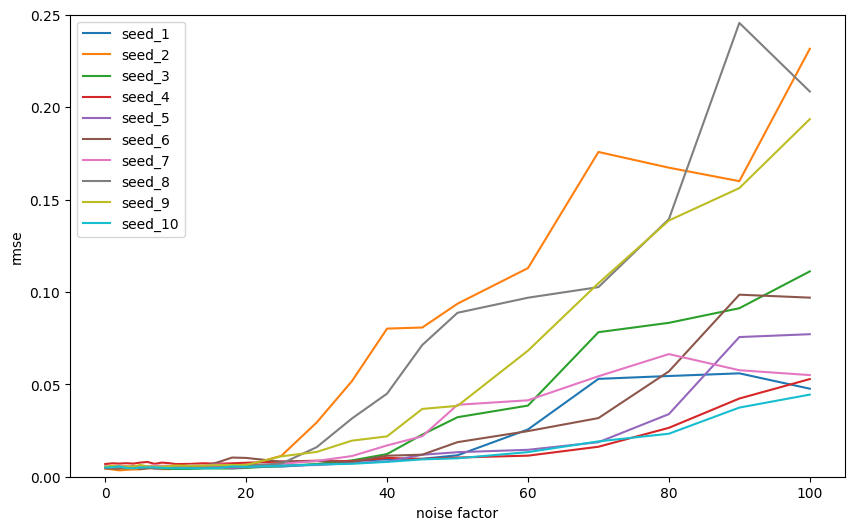

In [25]:
# plot the results
# x axis noise factor
# y axis rmse


fig, ax = plt.subplots(figsize=(10, 6))
for seed in range(max_seed):
    ax.plot(results[repr(seed)]['noise_factor'], results[repr(seed)]['rmse'], label=f'seed_{seed+1}')
ax.set_xlabel('noise factor')
ax.set_ylabel('rmse')
ax.legend()
ax.set_ylim(0, 0.25)

In [26]:
# early stop
# results[repr(seed)]['early_stop']
# merge all the early stop
num_noise_factor = len(results[repr(seed)]['noise_factor'])
print('num_noise_factor', num_noise_factor)
early_stop_results = [False for _ in range(num_noise_factor)]
print('early_stop_results', early_stop_results)
print('len(early_stop_results)', len(early_stop_results))
for seed in range(max_seed):
    for i in range(len(results[repr(seed)]['noise_factor'])):
        early_stop_results[i] = early_stop_results[i] or results[repr(seed)]['early_stop'][i]
print('early_stop_results', early_stop_results)
# find the first early stop
if True in early_stop_results:
    first_early_stop = early_stop_results.index(True)
    early_stop_noise_factor = results[repr(seed)]['noise_factor'][first_early_stop]
else:
    print('no early stop')
    first_early_stop = None
    early_stop_noise_factor = None
print('first_early_stop', first_early_stop)
print('early_stop_noise_factor', early_stop_noise_factor)

num_noise_factor 27
early_stop_results [False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False]
len(early_stop_results) 27
early_stop_results [[0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0]]
no early stop
first_early_stop None
early_stop_noise_factor None


#### pre-processing

In [27]:
# results

# compute results as np array
rmse = np.array([results[repr(seed)]['rmse'] for seed in range(max_seed)])
early_stop = np.array([results[repr(seed)]['early_stop'] for seed in range(max_seed)])
noise_factor = np.array([results[repr(seed)]['noise_factor'] for seed in range(max_seed)])
noise_factor = noise_factor[0]

# compute mean and std
rmse_mean = np.mean(rmse, axis=0)
rmse_std = np.std(rmse, axis=0)
rmse_max = np.max(rmse, axis=0)

# compute rmse degradation
rmse_degradation = rmse / rmse[:, 0][:, None] * 100
rmse_degradation_mean = np.mean(rmse_degradation, axis=0)
rmse_degradation_std = np.std(rmse_degradation, axis=0)


#### plotting

TypeError: unsupported operand type(s) for -: 'int' and 'NoneType'

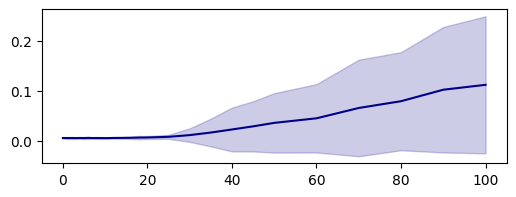

In [28]:
################################## plot rmse ##################################
fig, ax = plt.subplots(figsize=(6, 2))
ax.plot(noise_factor, rmse_mean, 
        label='mean', color=plot_color[controller])
ax.fill_between(noise_factor, rmse_mean- s*rmse_std, rmse_mean+ s*rmse_std, 
                alpha=0.2, label=f'{s} std', color=plot_color[controller])

# plot shaded area for the first early stop
ax.axvspan(early_stop_noise_factor, max_noise_factor, color='red', alpha=0.1, label='early stop')

ax.set_xlim([1, max_noise_factor])
ax.set_ylim([0, None])
# explicitly show the tick from 1 to the max noise factor
noise_ticks = [i for i in range(20, max_noise_factor+1, 20)]
# append 1 at the beginning
noise_ticks = [1] + noise_ticks
ax.set_xticks(noise_ticks)
# plot y line at 0.1
ax.axhline(y=0.1, color='gray', linestyle='--', label='RMSE = 0.1')
ax.legend(ncol=2)
ax.set_xlabel('Noise amplification factor')
ax.set_ylabel('RMSE')
ax.set_title(f'RMSE of {controller}{tag}')

# save the plot
# plot_file_name = f'{notebook_dir}/../data/{tag}_rmse_{controller}.png'
# plt.savefig(plot_file_name)

rmse_mean[0]

################################ plot rmse degradation ################################
fig, ax = plt.subplots(figsize=(6, 2))
ax.plot(noise_factor, rmse_degradation_mean, 
        label='mean', color=plot_color[controller])
ax.fill_between(noise_factor, rmse_degradation_mean- s*rmse_degradation_std, 
                rmse_degradation_mean+ s*rmse_degradation_std, alpha=0.2, label=f'{s} std', color=plot_color[controller])
ax.set_xlim([1, max_noise_factor])
ax.set_ylim([0, None])
# explicitly show the tick from 1 to the max noise factor
noise_ticks = [i for i in range(20, max_noise_factor+1, 20)]
# append 1 at the beginning
noise_ticks = [1] + noise_ticks
ax.set_xticks(noise_ticks)
# set y tick to be percentage
ax.set_yticklabels([f'{int(y)}%' for y in ax.get_yticks()])
ax.axhline(y=200, color='gray', linestyle='--', label='RMSE = 200%')
ax.legend()
ax.set_xlabel('Noise amplification factor')
ax.set_ylabel('RMSE degradation')
ax.set_title(f'RMSE degradation of {controller}{tag} with {noise_type}')

#### save results

In [ ]:
# results[repr(1)]['traj_steps']
# results.keys
print('rmse.shape', rmse.shape)
saved_results = {
    'rmse': rmse,
    'rmse_mean': rmse_mean,
    'rmse_std': rmse_std,
    'rmse_max': rmse_max,
    'rmse_degradation_mean': rmse_degradation_mean,
    'rmse_degradation_std': rmse_degradation_std,
    'noise_factor': noise_factor,
    'early_stop_noise_factor': early_stop_noise_factor,
    'early_stop': early_stop,
}
if controller in ['gpmpc_acados_TP']:
    results_file_name = f'{notebook_dir}/../data/{controller}{tag}_{noise_type}_results.npy'
else:
    results_file_name = f'{notebook_dir}/../data/{controller}_{noise_type}_results.npy'
# np.save(results_file_name, results)
np.save(results_file_name, saved_results)
print(f'saved {notebook_dir}/{results_file_name}')

results = np.load(results_file_name, allow_pickle=True).item()


rmse.shape (10, 18)
saved /home/mingxuan/Repositories/scg_tsung/benchmarking_sim/quadrotor/plotting//home/mingxuan/Repositories/scg_tsung/benchmarking_sim/quadrotor/plotting/../data/gpmpc_acados_TP_proc_ns=5_obs_noise_results.npy
